In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
uber_df=pd.read_csv('ncr_ride_bookings.csv')

In [3]:
uber_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

HERE date and time coloumn is in object format and cancelled ride by customer are in float64 and  cancelled tides by driver are also in float 64  here months colum should be added and these are the thing should be formated adn we must impute the missing values and clean non null objects 

In [5]:
uber_df.tail(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149990,2024-09-26,12:31:22,"""CNR3212810""",Cancelled by Driver,"""CID6199171""",Auto,Kashmere Gate ISBT,GTB Nagar,10.7,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149991,2024-07-13,14:47:30,"""CNR5591053""",Completed,"""CID1829616""",Auto,Karol Bagh,Vishwavidyalaya,11.2,30.8,...,NaN,NaN,NaN,NaN,NaN,597.0,27.91,4.2,4.3,UPI
149992,2024-01-24,18:02:28,"""CNR1717894""",No Driver Found,"""CID9564749""",Go Mini,Nehru Place,Aya Nagar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149993,2024-05-03,11:18:17,"""CNR9715958""",Completed,"""CID8835432""",Go Mini,Tughlakabad,Jama Masjid,13.2,20.1,...,NaN,NaN,NaN,NaN,NaN,280.0,29.89,4.1,4.7,Cash
149994,2024-06-14,16:46:53,"""CNR9572383""",Completed,"""CID2952237""",Go Mini,Akshardham,Greater Noida,8.2,30.6,...,NaN,NaN,NaN,NaN,NaN,388.0,10.51,4.3,4.9,UPI
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [6]:
uber_df.shape

(150000, 21)

In [7]:
uber_df.describe(include='all')

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,...,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,...,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID4523979""",Auto,Khandsa,Ashram,NaN,NaN,...,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,...,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,...,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,...,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,...,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,...,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,...,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,...,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


______CHECKING FOR THE DUPLICATED ROWS AND COLOUMNS_______________

In [8]:
dups=uber_df.duplicated()
print('number of duplicated row =%d' %dups.sum())
uber_df[dups]

number of duplicated row =0


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


In [9]:
list(uber_df.columns)

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [10]:
uber_df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [11]:
uber_df.tail(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149990,2024-09-26,12:31:22,"""CNR3212810""",Cancelled by Driver,"""CID6199171""",Auto,Kashmere Gate ISBT,GTB Nagar,10.7,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149991,2024-07-13,14:47:30,"""CNR5591053""",Completed,"""CID1829616""",Auto,Karol Bagh,Vishwavidyalaya,11.2,30.8,...,NaN,NaN,NaN,NaN,NaN,597.0,27.91,4.2,4.3,UPI
149992,2024-01-24,18:02:28,"""CNR1717894""",No Driver Found,"""CID9564749""",Go Mini,Nehru Place,Aya Nagar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149993,2024-05-03,11:18:17,"""CNR9715958""",Completed,"""CID8835432""",Go Mini,Tughlakabad,Jama Masjid,13.2,20.1,...,NaN,NaN,NaN,NaN,NaN,280.0,29.89,4.1,4.7,Cash
149994,2024-06-14,16:46:53,"""CNR9572383""",Completed,"""CID2952237""",Go Mini,Akshardham,Greater Noida,8.2,30.6,...,NaN,NaN,NaN,NaN,NaN,388.0,10.51,4.3,4.9,UPI
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


REMOVING UNWANTED COLUMNS 
since incomplete rides and cancelled rides by driver are just the nan and one values i removed it 
we have exact simmilar columns that Incomplete Rides Reason and Reason for cancelling by Customer.

In [12]:
uber_df.drop('Incomplete Rides',axis=1,inplace=True)

In [13]:
uber_df.drop('Cancelled Rides by Driver',axis=1,inplace=True)

In [14]:
uber_df.drop('Cancelled Rides by Customer',axis=1,inplace=True)

In [15]:
uber_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


______________________________________FILLING MISSING VALUE__________

In [16]:
uber_df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [17]:
##removing null or missing value in numeric colums 
numerical_columns=uber_df.select_dtypes(include=[np.number]).columns
list(numerical_columns)
for col in numerical_columns:
    median=uber_df[col].median()
    uber_df[col].replace(np.nan,median,inplace=True)
uber_df.isna().sum()

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\1631875813.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uber_df[col].replace(np.nan,median,inplace=True)


Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                                  0
Avg CTAT                                  0
Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Incomplete Rides Reason              141000
Booking Value                             0
Ride Distance                             0
Driver Ratings                            0
Customer Rating                           0
Payment Method                        48000
dtype: int64

In [18]:
uber_df['Payment Method'].fillna('Unknown', inplace=True)

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\3992741877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uber_df['Payment Method'].fillna('Unknown', inplace=True)


In [19]:
uber_df['Reason for cancelling by Customer'].fillna('Not cancelled',inplace=True)
uber_df['Driver Cancellation Reason'].fillna('Not cancelled',inplace=True)
uber_df['Incomplete Rides Reason'].fillna('Ride completed',inplace=True) 

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\4093429187.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uber_df['Reason for cancelling by Customer'].fillna('Not cancelled',inplace=True)
C:\Users\hai\AppData\Local\Temp\ipykernel_11764\4093429187.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [20]:
uber_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,Not cancelled,Not cancelled,Ride completed,414.0,23.72,4.3,4.5,Unknown
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,Not cancelled,Not cancelled,Vehicle Breakdown,237.0,5.73,4.3,4.5,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,Not cancelled,Not cancelled,Ride completed,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,Not cancelled,Not cancelled,Ride completed,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,Not cancelled,Not cancelled,Ride completed,737.0,48.21,4.1,4.3,UPI


FORMATING THE CORRECT DATATYPE 

In [21]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Reason for cancelling by Customer  150000 non-null  object 
 11  Driver Cancellation Reason         1500

HERE ALL ARE AT CORRECT DATA TYPE EXCPET DATE SO WE ARE GOING TO FORMAT DATE USING PANDAS DATETIME FORMAT 

In [23]:
uber_df['Date'] = pd.to_datetime(uber_df['Date'])

In [24]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Reason for cancellin

_____________________________ANALYSIS____________________________

WHICH VEHICLE TYPE PEOPLE PREFER OFTEN ?

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\1368127034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=uber_df,x='Vehicle Type',palette='coolwarm')


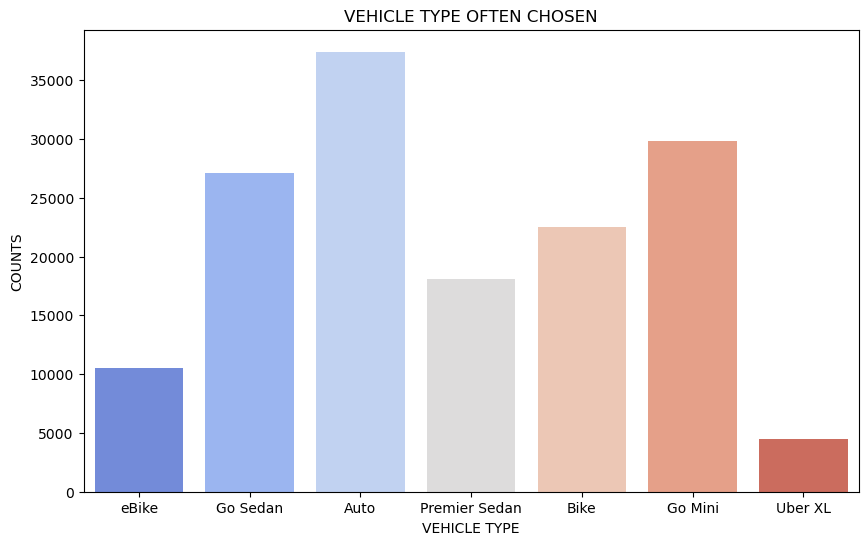

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Vehicle Type',palette='coolwarm')
plt.title('VEHICLE TYPE OFTEN CHOSEN')
plt.xlabel('VEHICLE TYPE')
plt.ylabel('COUNTS')
plt.show()

BOOKING VALUE BASED ON VEHICLE TYPE 

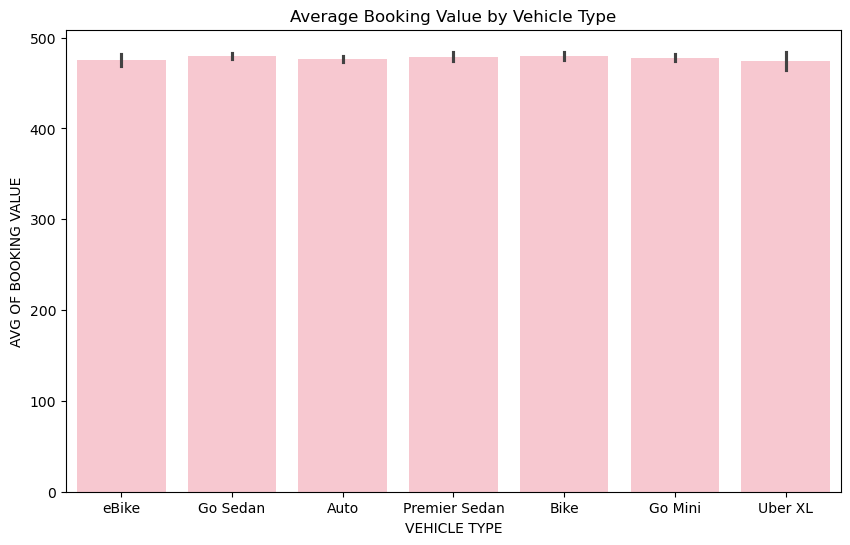

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='Vehicle Type',y='Booking Value',estimator='mean',color='pink')
plt.title('Average Booking Value by Vehicle Type')
plt.xlabel('VEHICLE TYPE')
plt.ylabel('AVG OF BOOKING VALUE')
plt.show()

BASED ON THE RIDE DISTANCE WHICH VEHICLE IS CHOOSEN OFTEN

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\1655070813.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=uber_df,x='Vehicle Type',y='Ride Distance',estimator='mean',color='skyblue',ci=None)


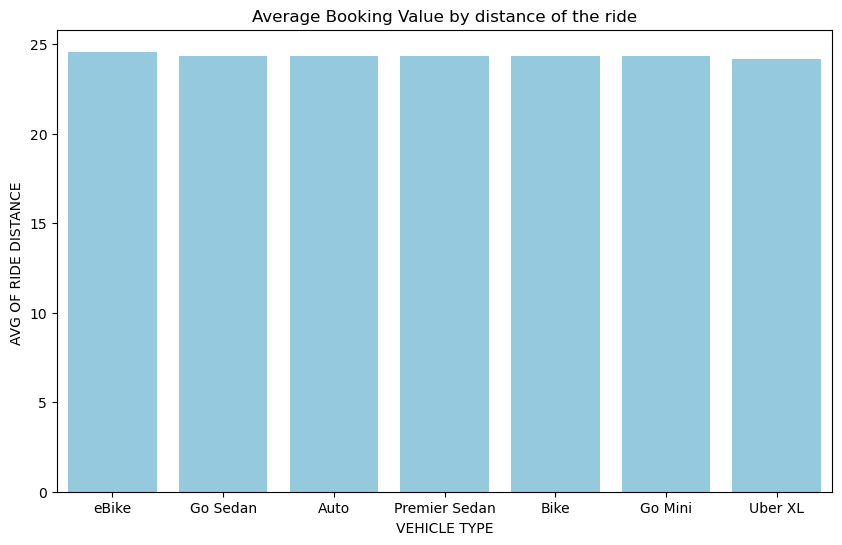

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='Vehicle Type',y='Ride Distance',estimator='mean',color='skyblue',ci=None)
plt.title('Average Booking Value by distance of the ride')
plt.xlabel('VEHICLE TYPE')
plt.ylabel('AVG OF RIDE DISTANCE ')
plt.show()

WHICH VEHICLE TYPE CHOOSE OVER THE TIME AND DAY ?

In [28]:
uber_df['Hour'] = pd.to_datetime(uber_df['Time'],format='%H:%M:%S').dt.hour

uber_df['DAY'] = pd.cut(uber_df['Hour'],bins=[0,10,15,19,24],labels=['Morning','Afternoon','Evening','Night'],include_lowest=True)

In [29]:
uber_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,DAY
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,Not cancelled,Not cancelled,Ride completed,414.0,23.72,4.3,4.5,Unknown,12,Afternoon
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,Not cancelled,Not cancelled,Vehicle Breakdown,237.0,5.73,4.3,4.5,UPI,18,Evening
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,Not cancelled,Not cancelled,Ride completed,627.0,13.58,4.9,4.9,Debit Card,8,Morning
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,Not cancelled,Not cancelled,Ride completed,416.0,34.02,4.6,5.0,UPI,17,Evening
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,Not cancelled,Not cancelled,Ride completed,737.0,48.21,4.1,4.3,UPI,22,Night


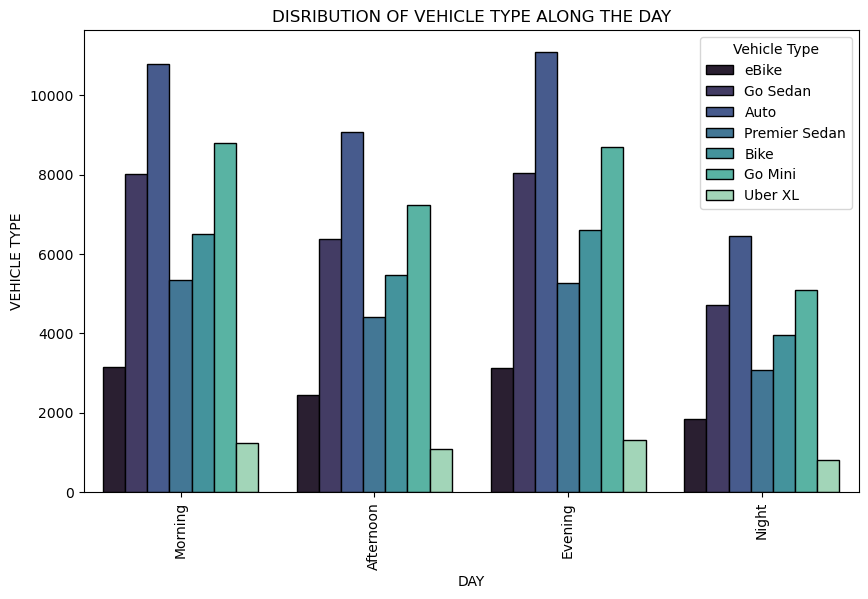

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='DAY',hue='Vehicle Type',palette='mako',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('DAY')
plt.ylabel('VEHICLE TYPE')
plt.title('DISRIBUTION OF VEHICLE TYPE ALONG THE DAY')
plt.show()

THE COUNT PLOT OF DAY WHICH TIME THE BOKKING WAS PEAK DAY OR NIGHT ?

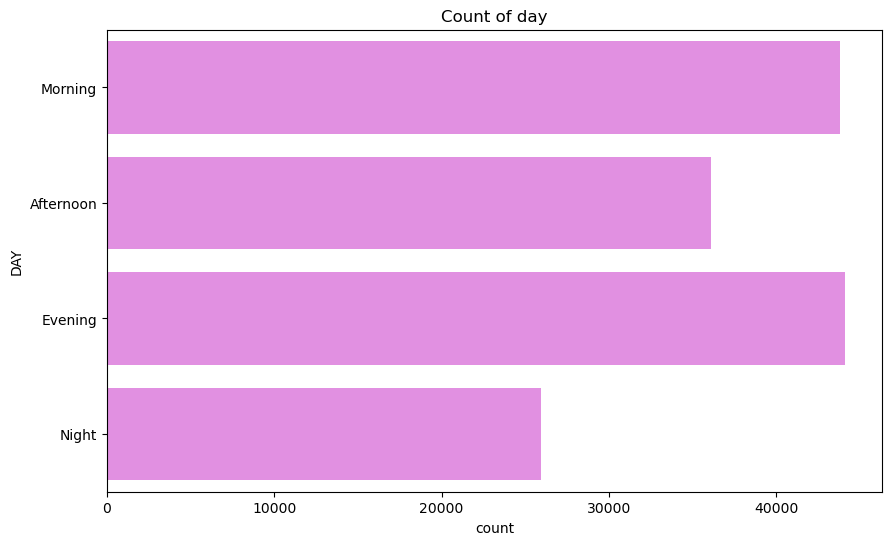

In [31]:
plt.figure(figsize=(10,6))
plt.title('Count of day')
sns.countplot(uber_df['DAY'],color='violet')
plt.show()

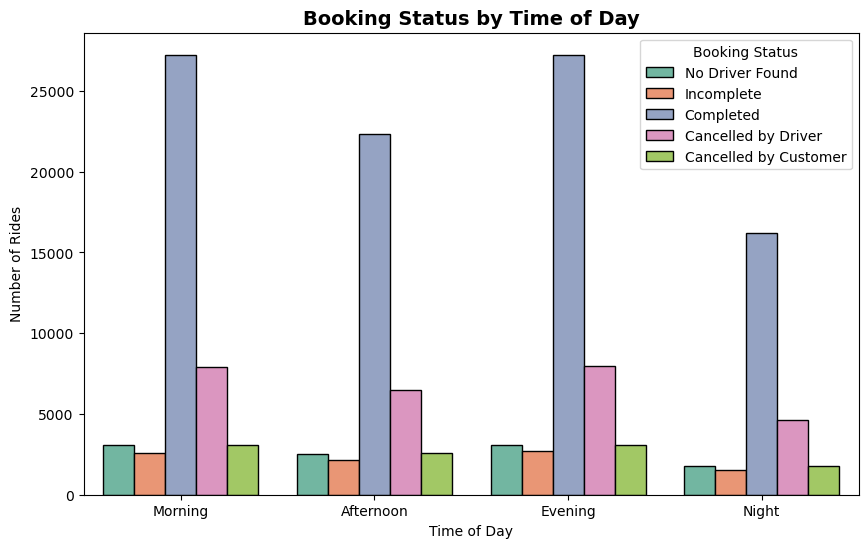

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(data=uber_df,x='DAY',hue='Booking Status',palette='Set2',edgecolor='black')

plt.title('Booking Status by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day')
plt.ylabel('Number of Rides')
plt.legend(title='Booking Status')
plt.show()

AVERAGE  THE VEHICLE TURN AROUND TIME DEPONDING ON VEHICLE TYPE

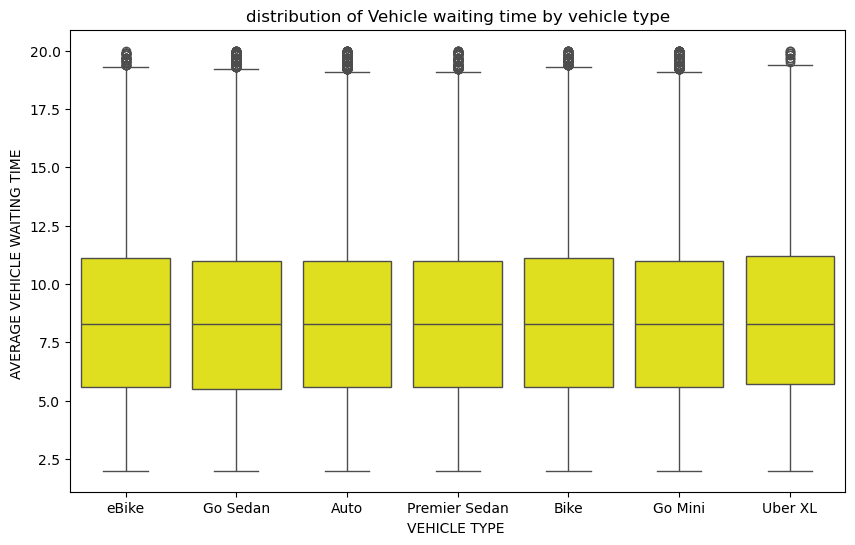

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Vehicle Type',y='Avg VTAT',color='yellow')
plt.title('distribution of Vehicle waiting time by vehicle type')
plt.ylabel('AVERAGE VEHICLE WAITING TIME ')
plt.xlabel('VEHICLE TYPE ')
plt.show()

AVERAGE OF CUSTOMER TRUN AROUND TIME DEPONDING ON THE VEHICLE TYPE

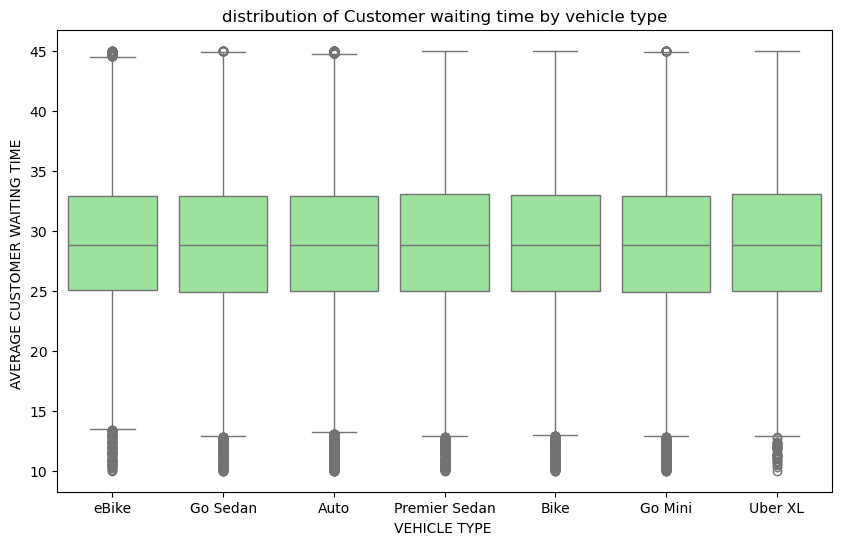

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Vehicle Type',y='Avg CTAT',color='lightgreen')
plt.title('distribution of Customer waiting time by vehicle type')
plt.ylabel('AVERAGE CUSTOMER WAITING TIME ')
plt.xlabel('VEHICLE TYPE ')
plt.show()

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\3116178843.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  sns.countplot(data= uber_df,y='Pickup Location',order=pd.value_counts(uber_df['Pickup Location']).iloc[:10].index,palette='viridis',edgecolor='black')
C:\Users\hai\AppData\Local\Temp\ipykernel_11764\3116178843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= uber_df,y='Pickup Location',order=pd.value_counts(uber_df['Pickup Location']).iloc[:10].index,palette='viridis',edgecolor='black')


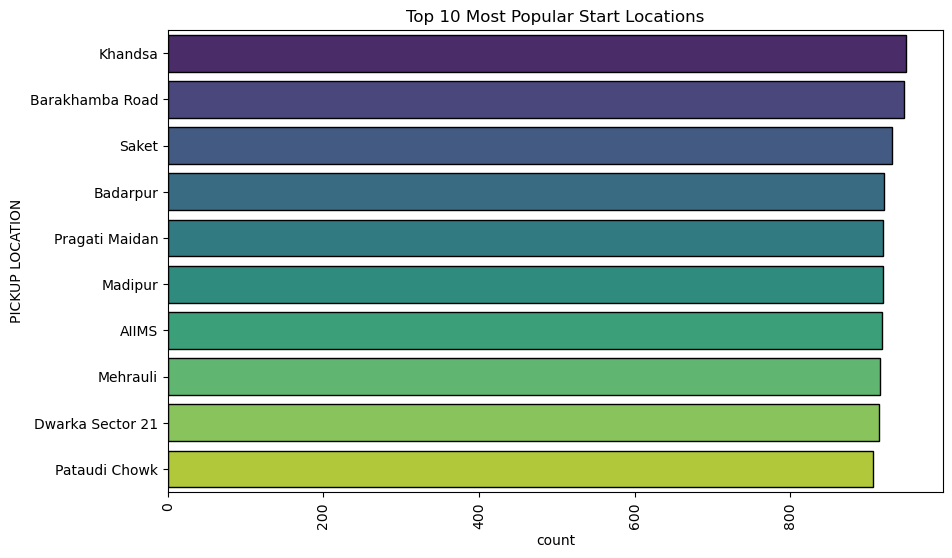

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(data= uber_df,y='Pickup Location',order=pd.value_counts(uber_df['Pickup Location']).iloc[:10].index,palette='viridis',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('count')
plt.ylabel('PICKUP LOCATION')
plt.title('Top 10 Most Popular Start Locations')
plt.show()

C:\Users\hai\AppData\Local\Temp\ipykernel_11764\413726707.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  sns.countplot(data= uber_df,y='Drop Location',order=pd.value_counts(uber_df['Drop Location']).iloc[:10].index,palette='viridis',edgecolor='black')
C:\Users\hai\AppData\Local\Temp\ipykernel_11764\413726707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= uber_df,y='Drop Location',order=pd.value_counts(uber_df['Drop Location']).iloc[:10].index,palette='viridis',edgecolor='black')


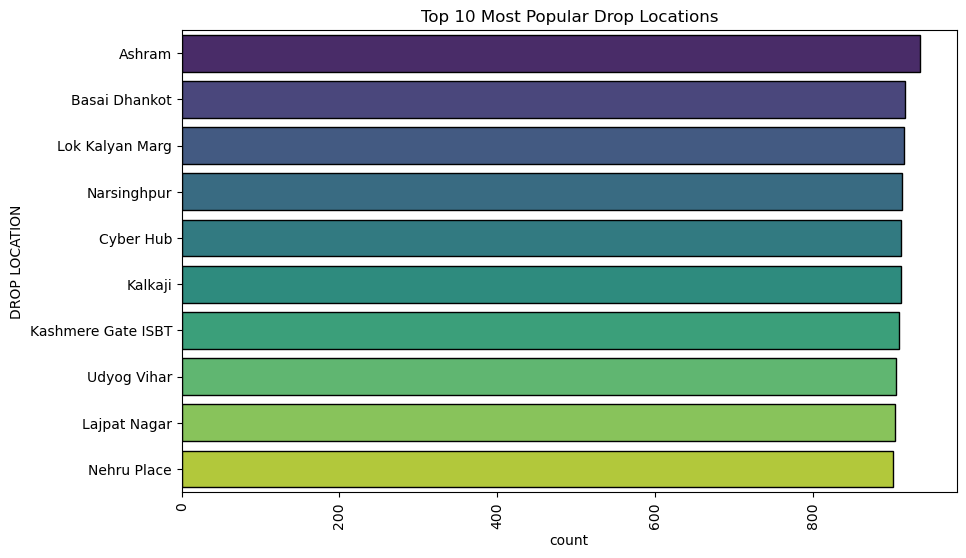

In [36]:
plt.figure(figsize=(10,6))
sns.countplot(data= uber_df,y='Drop Location',order=pd.value_counts(uber_df['Drop Location']).iloc[:10].index,palette='viridis',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('count')
plt.ylabel('DROP LOCATION')
plt.title('Top 10 Most Popular Drop Locations')
plt.show()

COUNTS OF BOOKING STATUS 

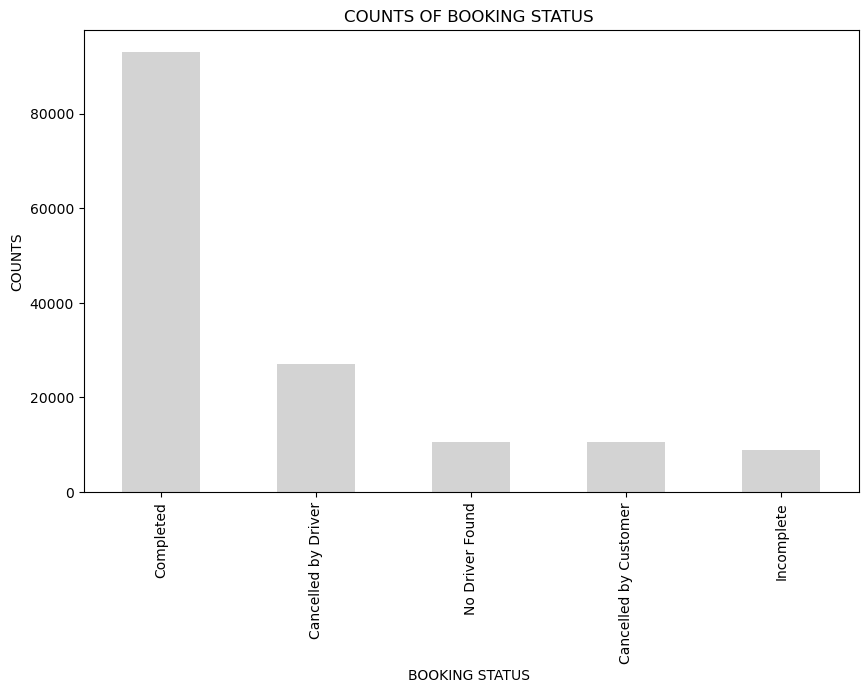

In [37]:
plt.figure(figsize=(10,6))
uber_df['Booking Status'].value_counts().plot(kind='bar',color='lightgrey')
plt.xlabel('BOOKING STATUS ')
plt.title('COUNTS OF BOOKING STATUS ')
plt.ylabel('COUNTS')
plt.show()

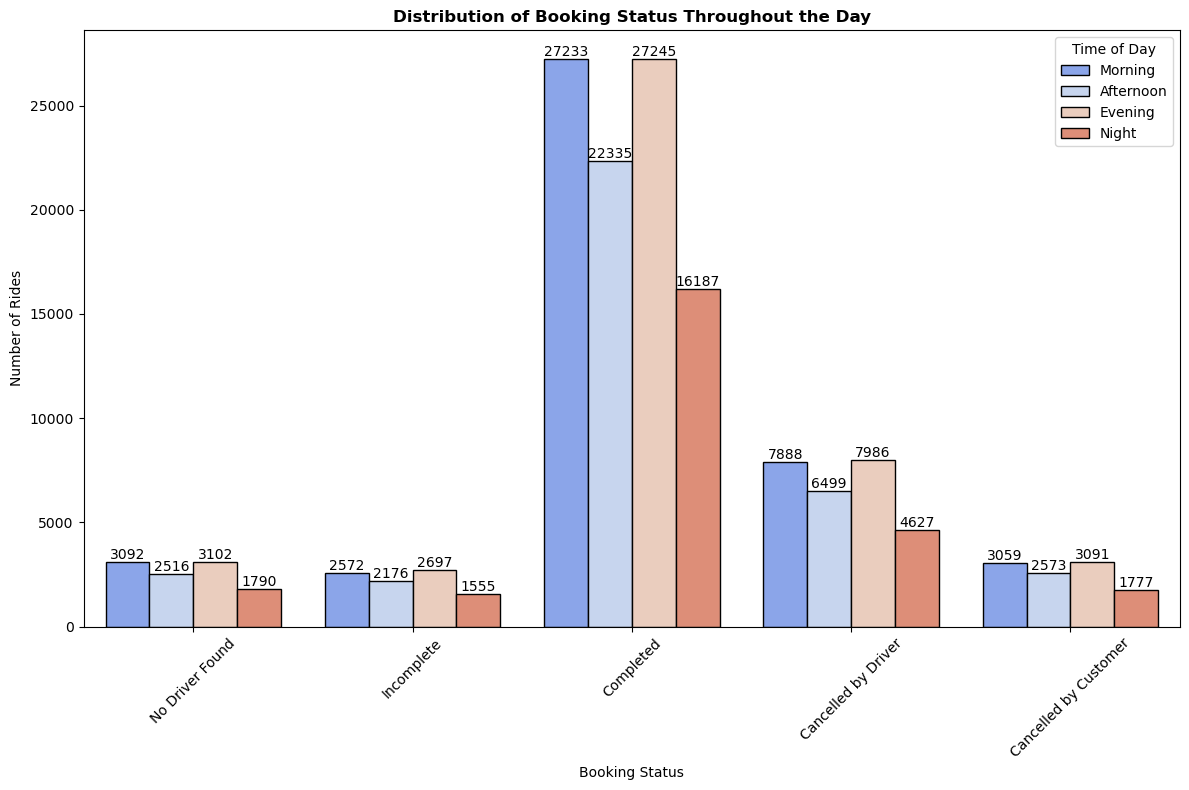

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns  
plt.figure(figsize=(12,8))
ax = sns.countplot(data=uber_df,x='Booking Status',hue='DAY',palette='coolwarm',edgecolor='black') 
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.xticks(rotation=45)
plt.xlabel('Booking Status')
plt.ylabel('Number of Rides')
plt.title('Distribution of Booking Status Throughout the Day',fontweight='bold')
plt.legend(title='Time of Day')
plt.tight_layout()
plt.show()

DISTRIBUTION OF THE VEHICLE TYPE ALONG THE DAY 

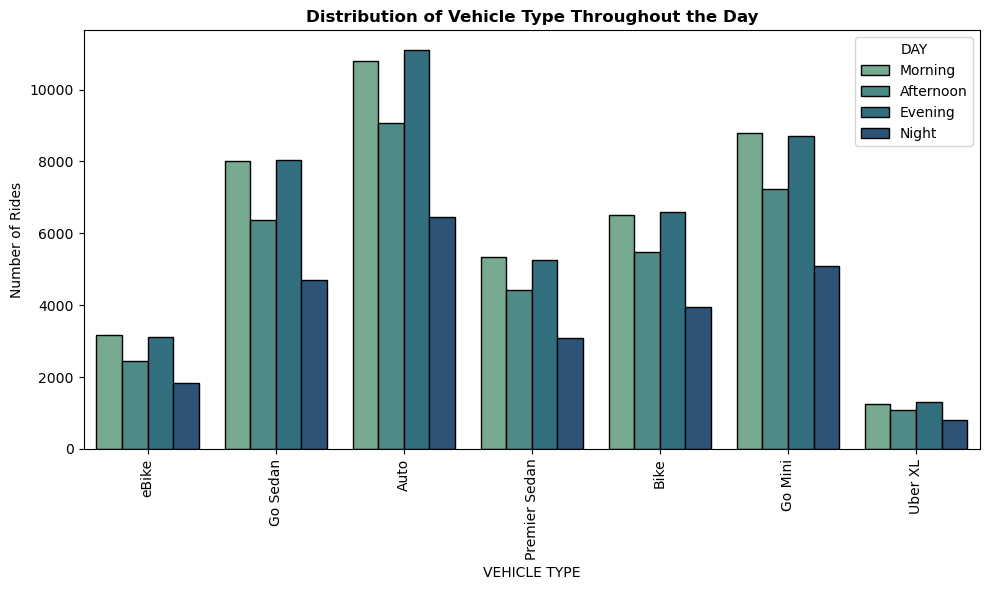

In [39]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=uber_df,x='Vehicle Type',hue='DAY',palette='crest',edgecolor='black') 
plt.xticks(rotation=90)
plt.xlabel('VEHICLE TYPE')
plt.ylabel('Number of Rides')
plt.title('Distribution of Vehicle Type Throughout the Day',fontweight='bold')
plt.tight_layout()
plt.show()

DISTRIBUTION OF RIDEDISTANCE ALONG THE BOOKING VALUE 

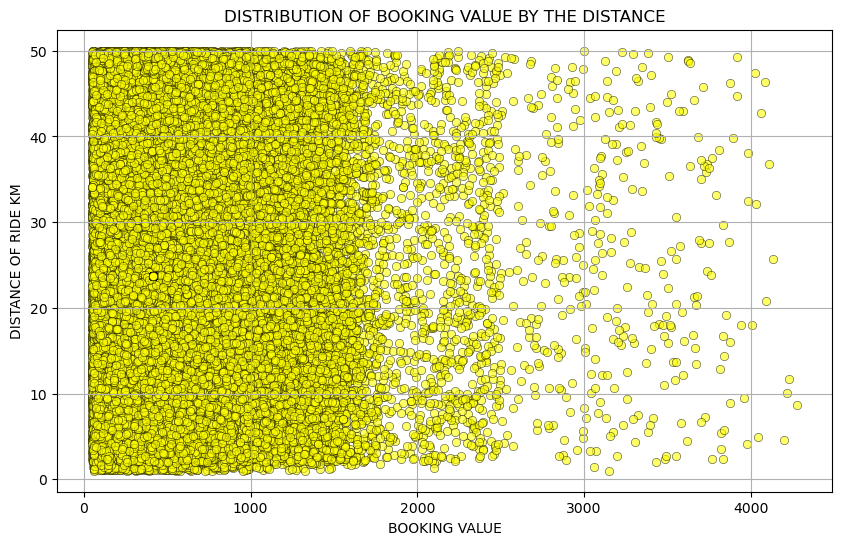

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber_df,x='Booking Value',y='Ride Distance',marker='o',color='yellow',alpha=0.6,edgecolor='black')
plt.title('DISTRIBUTION OF BOOKING VALUE BY THE DISTANCE')
plt.xlabel('BOOKING VALUE')
plt.ylabel('DISTANCE OF RIDE KM')
plt.grid(True)
plt.show()

THE FREQUENCY OF THE CUSTOMER RATINGS OVER THE DISTANCE OF THE TRIP

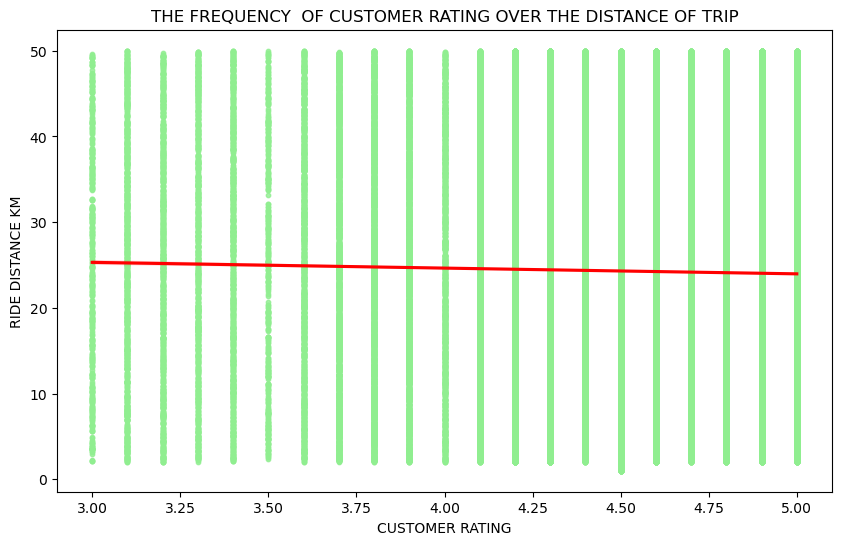

In [45]:
import warnings
warnings.filterwarnings('ignore',category=UserWarning)
plt.figure(figsize=(10,6))
sns.regplot(data=uber_df,x='Customer Rating',y='Ride Distance',color='lightgreen',scatter_kws={'s':10},line_kws={'color':'red'})
plt.title('THE FREQUENCY  OF CUSTOMER RATING OVER THE DISTANCE OF TRIP')
plt.xlabel('CUSTOMER RATING')
plt.ylabel('RIDE DISTANCE KM')
plt.show()

FREQUENCY OF THE DRIVER RATING OVER THE DISTANCE OF THE RIDE 

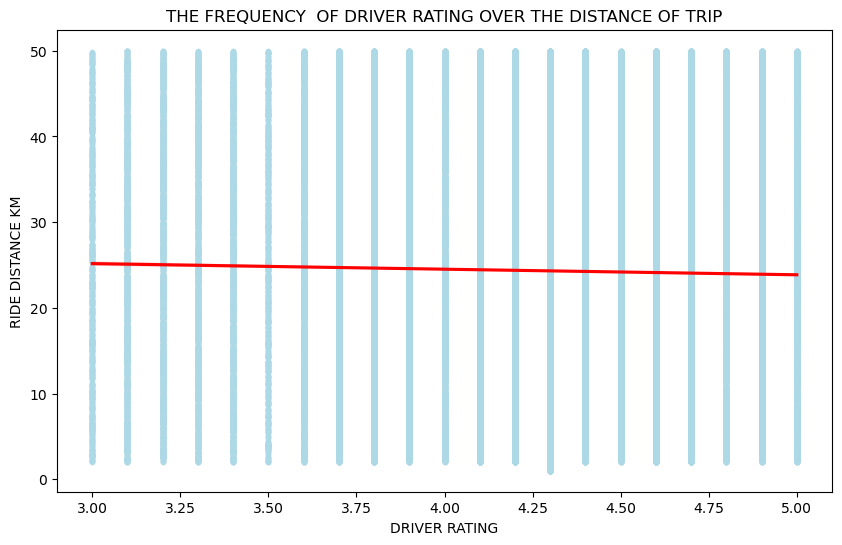

In [47]:
import warnings
warnings.filterwarnings('ignore',category=UserWarning)
plt.figure(figsize=(10,6))
sns.regplot(data=uber_df,x='Driver Ratings',y='Ride Distance',color='lightblue',scatter_kws={'s':10},line_kws={'color':'red'})
plt.title('THE FREQUENCY  OF DRIVER RATING OVER THE DISTANCE OF TRIP')
plt.xlabel('DRIVER RATING')
plt.ylabel('RIDE DISTANCE KM')
plt.show()

TH COUNT PLOT OF THE PAYMENT METHOD 

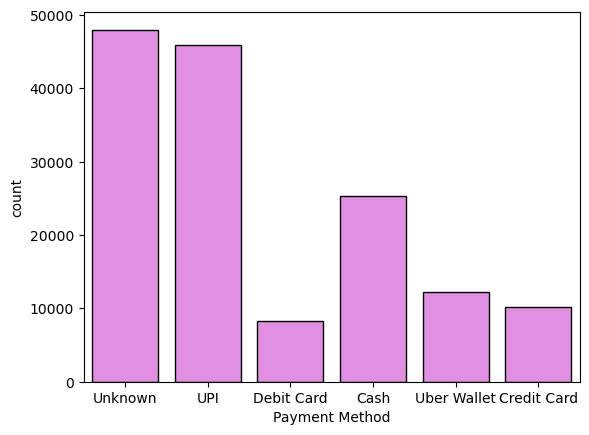

In [50]:
sns.countplot(data=uber_df,x='Payment Method',color='violet',edgecolor='black')
plt.show()

THE MOST  REASON FOR INCOMPLETE RIDES 

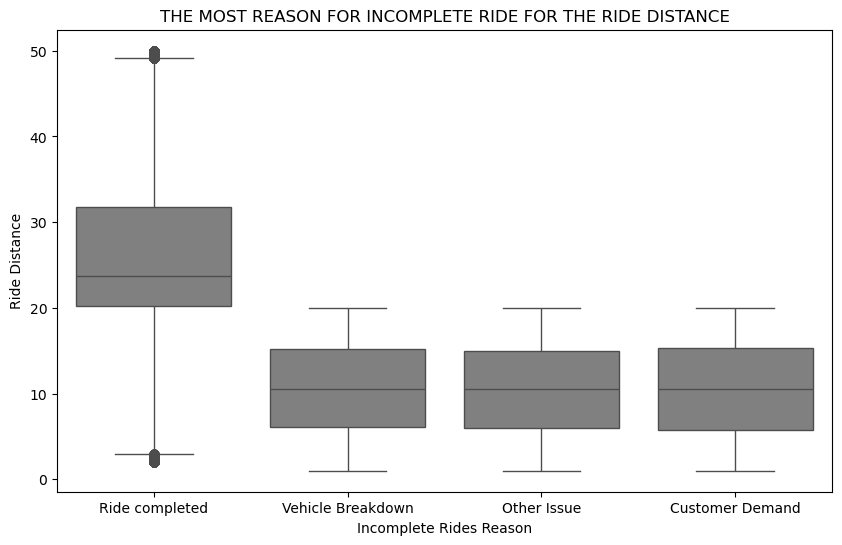

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Incomplete Rides Reason',y='Ride Distance',color='grey')
plt.title('THE MOST REASON FOR INCOMPLETE RIDE FOR THE RIDE DISTANCE')
plt.show()

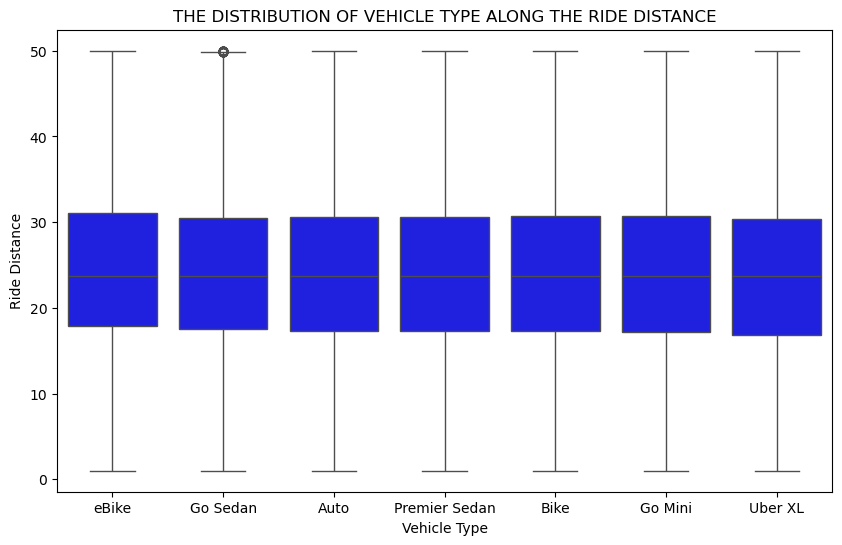

In [55]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Vehicle Type',y='Ride Distance',color='blue')
plt.title('THE DISTRIBUTION OF VEHICLE TYPE ALONG THE RIDE DISTANCE')
plt.show()

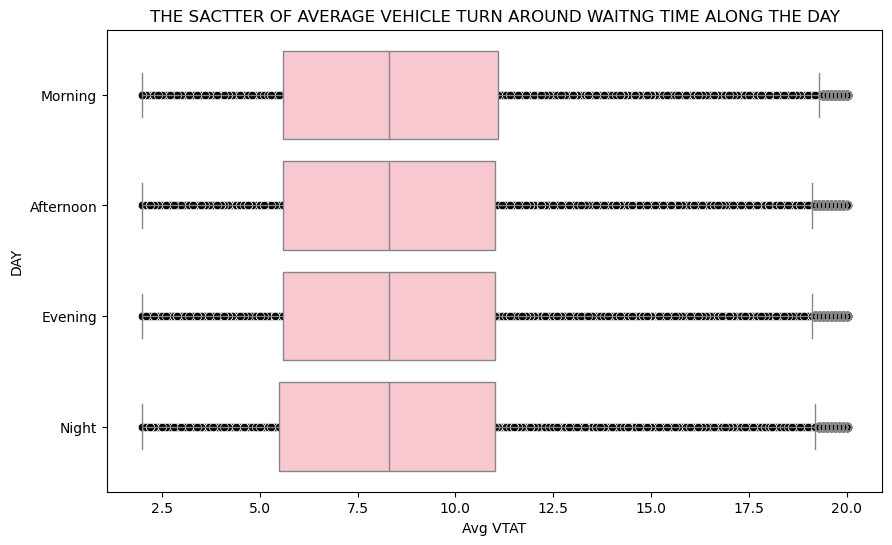

In [56]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Avg VTAT',y='DAY',color='pink')
sns.scatterplot(data=uber_df,x='Avg VTAT',y='DAY',color='black')
plt.title('THE SACTTER OF AVERAGE VEHICLE TURN AROUND WAITNG TIME ALONG THE DAY')
plt.show()

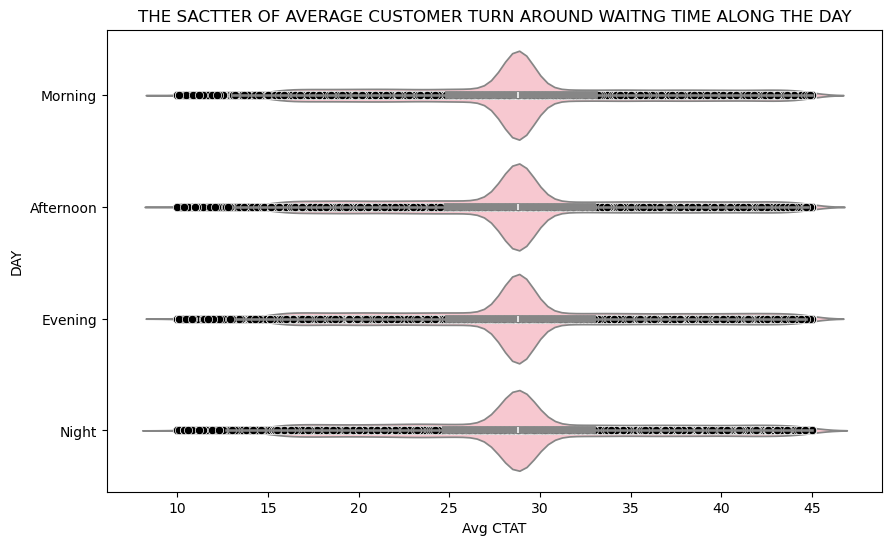

In [57]:
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df,x='Avg CTAT',y='DAY',color='pink')
sns.scatterplot(data=uber_df,x='Avg CTAT',y='DAY',color='black')
plt.title('THE SACTTER OF AVERAGE CUSTOMER TURN AROUND WAITNG TIME ALONG THE DAY')
plt.show()

<Figure size 1000x600 with 0 Axes>

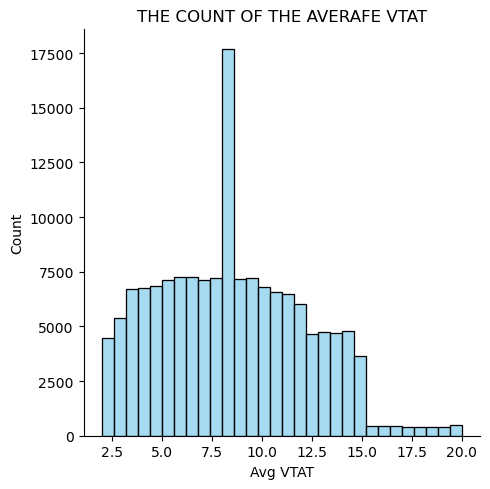

In [59]:
plt.figure(figsize=(10,6))
sns.displot(uber_df['Avg VTAT'],bins=30,color='skyblue',edgecolor='black')
plt.title('THE COUNT OF THE AVERAGE VTAT')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

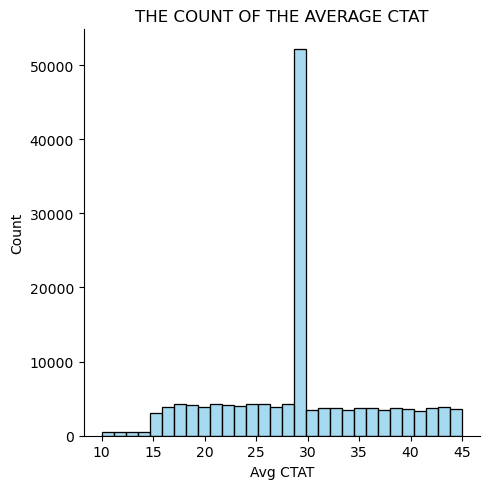

In [60]:
plt.figure(figsize=(10,6))
sns.displot(uber_df['Avg CTAT'],bins=30,color='skyblue',edgecolor='black')
plt.title('THE COUNT OF THE AVERAGE CTAT')
plt.tight_layout()
plt.show()

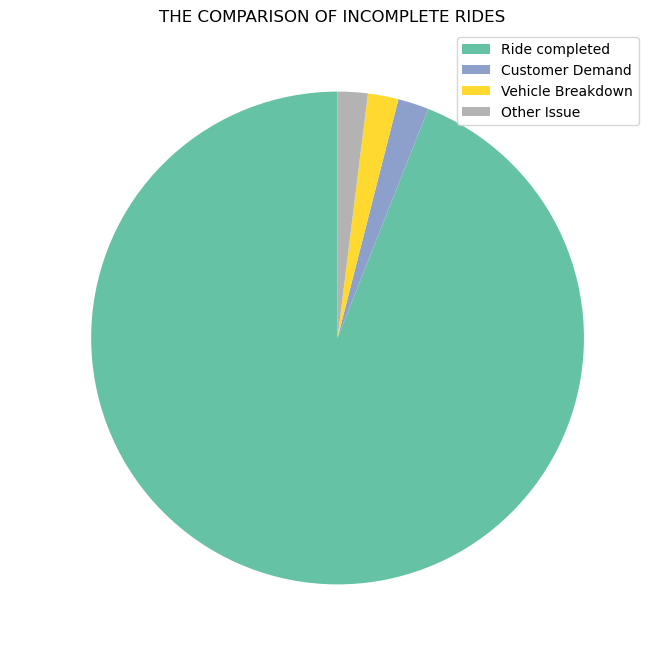

In [61]:
plt.figure(figsize=(8,8))
 
uber_df['Incomplete Rides Reason'].value_counts().plot.pie(autopct= None ,startangle=90,cmap='Set2',labels=None)
plt.title('THE COMPARISON OF INCOMPLETE RIDES  ')
plt.ylabel(' ')
plt.legend(labels=uber_df['Incomplete Rides Reason'].value_counts('Incomplete Rides Reason').index,loc='upper right')
plt.show()

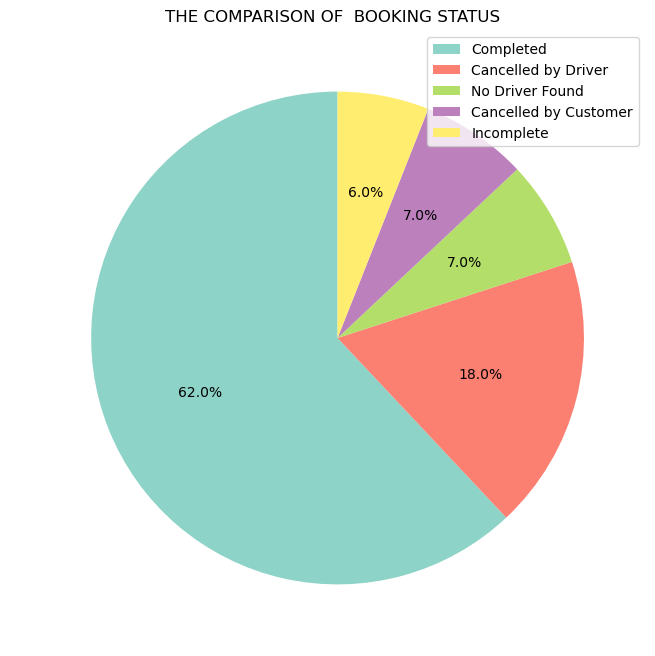

In [68]:
plt.figure(figsize=(8,8))
 
uber_df['Booking Status'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='Set3',labels=None)
plt.title('THE COMPARISON OF  BOOKING STATUS  ')
plt.ylabel(' ')
plt.legend(labels=uber_df['Booking Status'].value_counts('Booking Status').index,loc='upper right')
plt.show()

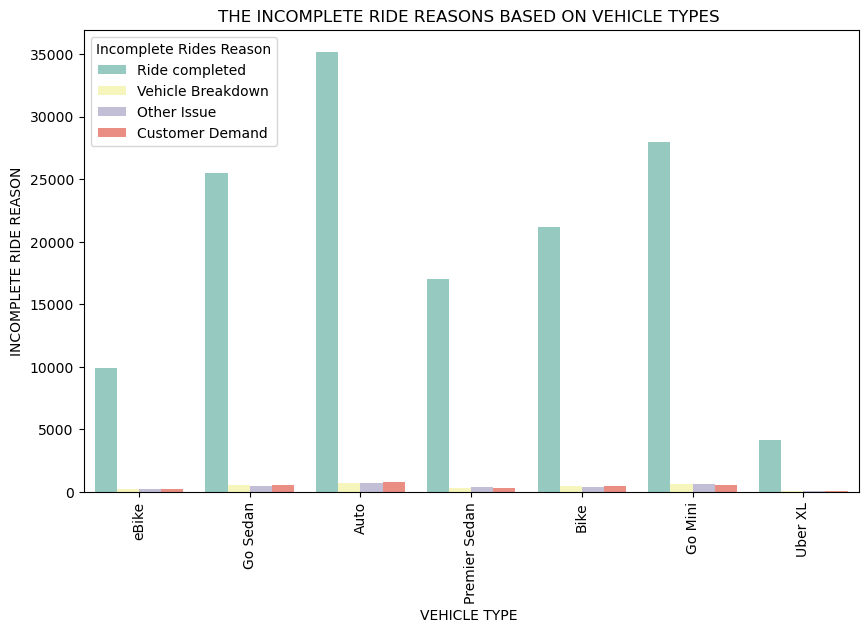

In [69]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Vehicle Type',hue='Incomplete Rides Reason',palette='Set3')
plt.xticks(rotation=90)
plt.xlabel('VEHICLE TYPE ')
plt.ylabel('INCOMPLETE RIDE REASON')
plt.title('THE INCOMPLETE RIDE REASONS BASED ON VEHICLE TYPES ')
plt.show()

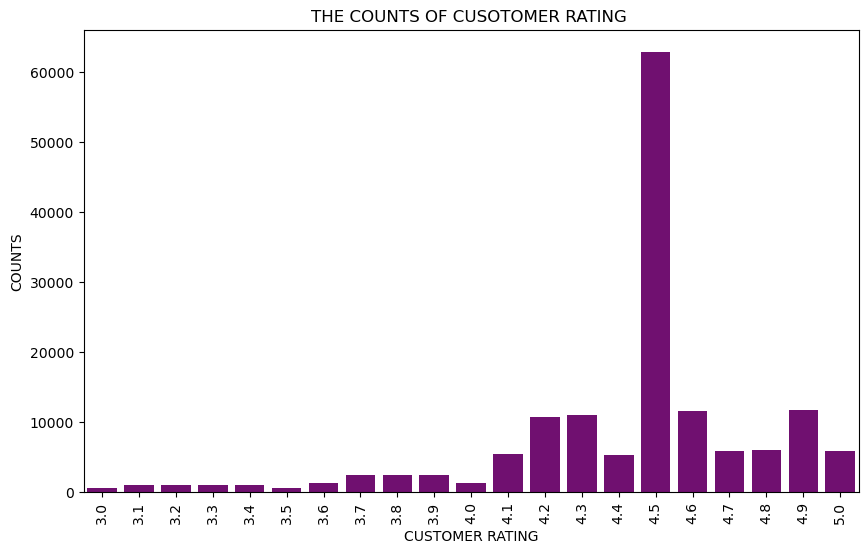

In [71]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Customer Rating',color='purple')
plt.xticks(rotation=90)
plt.xlabel('CUSTOMER RATING')
plt.ylabel('COUNTS')
plt.title('THE COUNTS OF CUSOTOMER RATING ')
plt.show()

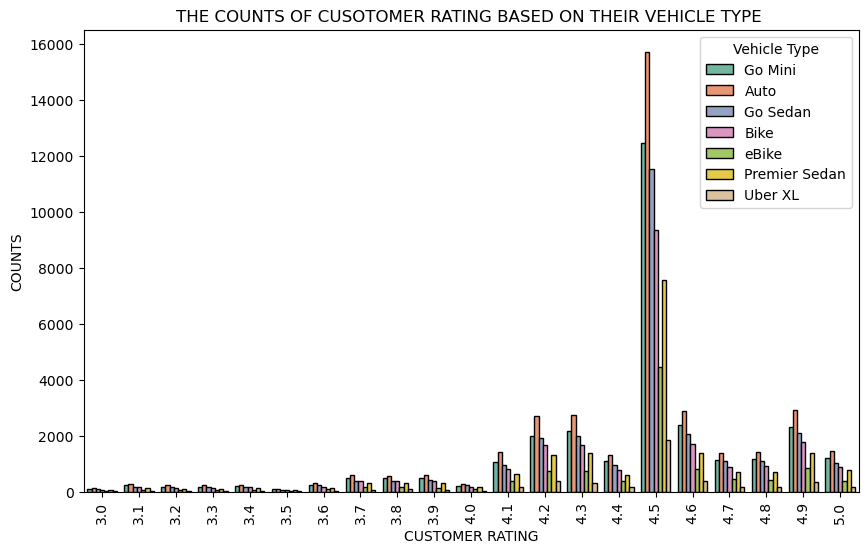

In [81]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Customer Rating',hue='Vehicle Type',palette='Set2',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('CUSTOMER RATING')
plt.ylabel('COUNTS')
plt.title('THE COUNTS OF CUSOTOMER RATING BASED ON THEIR VEHICLE TYPE ')
plt.show()

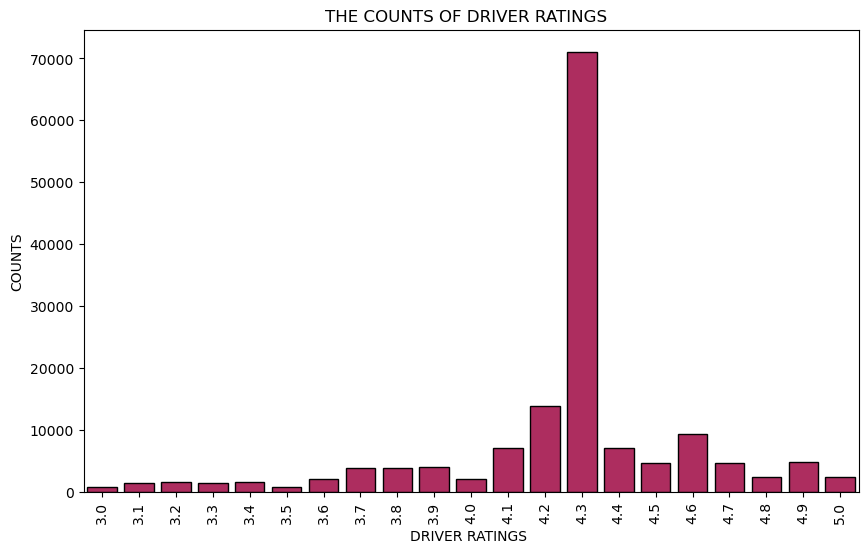

In [83]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Driver Ratings',color='#C2185B',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('DRIVER RATINGS ')
plt.ylabel('COUNTS')
plt.title('THE COUNTS OF DRIVER RATINGS  ')
plt.show()

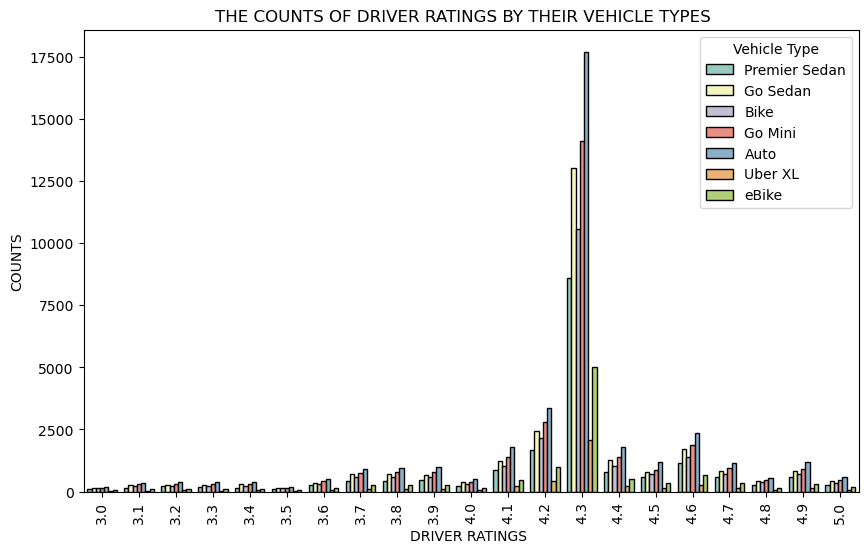

In [85]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='Driver Ratings',hue='Vehicle Type',palette='Set3',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel('DRIVER RATINGS ')
plt.ylabel('COUNTS')
plt.title('THE COUNTS OF DRIVER RATINGS BY THEIR VEHICLE TYPES   ')
plt.show()

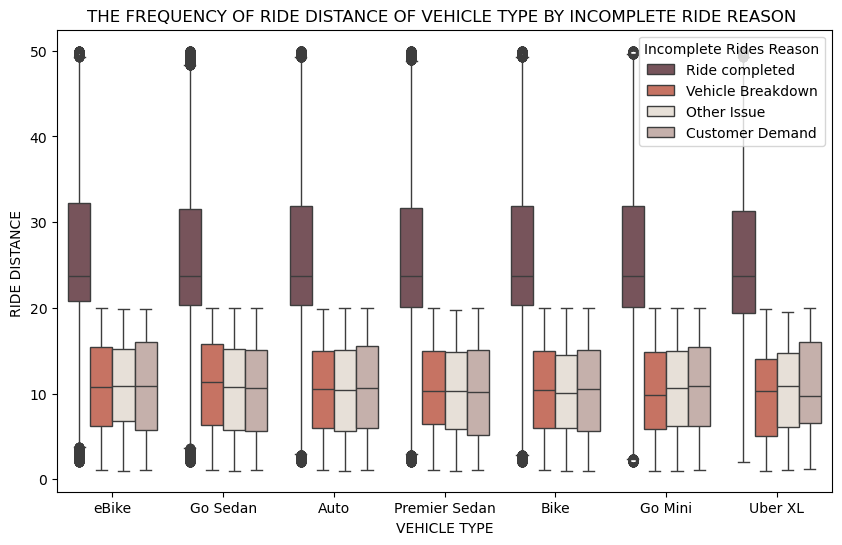

In [87]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='Vehicle Type',y='Ride Distance',hue='Incomplete Rides Reason',palette = ['#7D4E57', '#D66853', '#EAE0D5', '#C9ADA7', '#9A8C98'])
plt.xlabel('VEHICLE TYPE')
plt.ylabel('RIDE DISTANCE ')
plt.title('THE FREQUENCY OF RIDE DISTANCE OF VEHICLE TYPE BY INCOMPLETE RIDE REASON ')
plt.show()

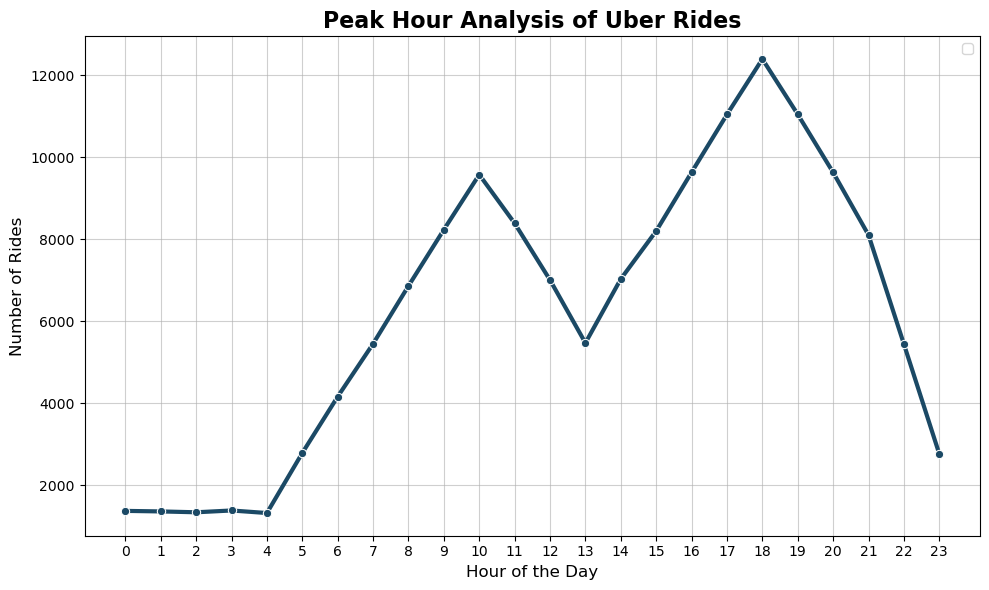

In [90]:
hourly_rides = uber_df.groupby('Hour').size().reset_index(name='Ride Count')
plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_rides,
    x='Hour',
    y='Ride Count',
    marker='o',
    linewidth=3,
    color='#1B4965'   

)



plt.title('Peak Hour Analysis of Uber Rides', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True,alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

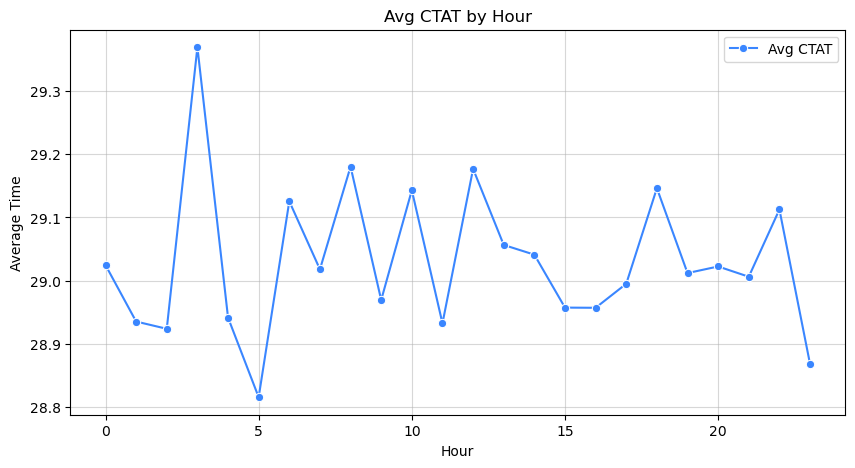

In [93]:
avg_time = uber_df.groupby('Hour')[['Avg CTAT', 'Avg VTAT']].mean()

plt.figure(figsize=(10,5))

sns.lineplot(data=avg_time, x=avg_time.index, y='Avg CTAT', label='Avg CTAT',marker='o',color='#3A86FF')

plt.title('Avg CTAT by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Time')
plt.grid(True,alpha=0.5)
plt.legend()
plt.show()

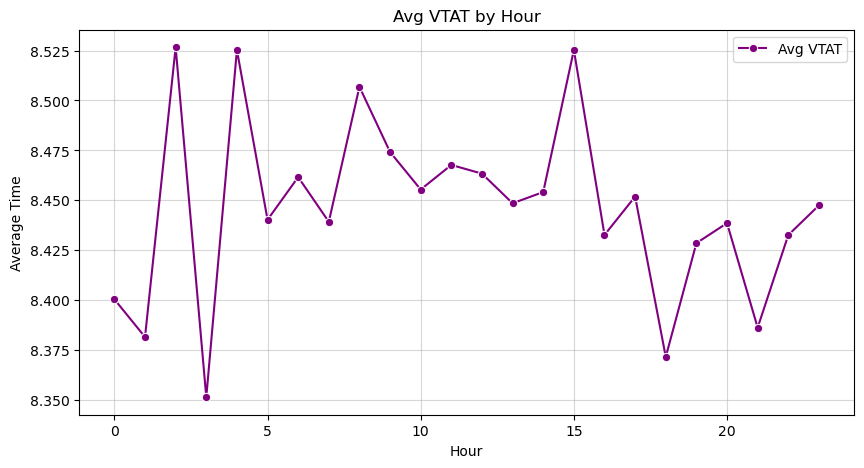

In [95]:
avg_time = uber_df.groupby('Hour')[['Avg CTAT', 'Avg VTAT']].mean()

plt.figure(figsize=(10,5))

sns.lineplot(data=avg_time, x=avg_time.index, y='Avg VTAT', label='Avg VTAT',marker='o',color='purple')

plt.title('Avg VTAT by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Time')
plt.grid(True,alpha=0.5)
plt.legend()
plt.show()

In [104]:
frequent_booking_id = (
    uber_df['Booking ID']
    .value_counts()
    .head(10)
    .reset_index()
)
df=pd.DataFrame(frequent_booking_id)
print(df)

     Booking ID  count
0  "CNR7908610"      3
1  "CNR9603232"      3
2  "CNR7199036"      3
3  "CNR6337479"      3
4  "CNR5292943"      3
5  "CNR3648267"      3
6  "CNR7585544"      3
7  "CNR2726142"      3
8  "CNR7642097"      3
9  "CNR9543990"      2


    Customer ID  count
0  "CID4523979"      3
1  "CID8727691"      3
2  "CID5481002"      3
3  "CID6715450"      3
4  "CID7828101"      3
5  "CID6468528"      3
6  "CID4726416"      2
7  "CID3071903"      2
8  "CID6797938"      2
9  "CID2643961"      2


C:\Users\hai\AppData\Local\Temp\ipykernel_11764\2780101348.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


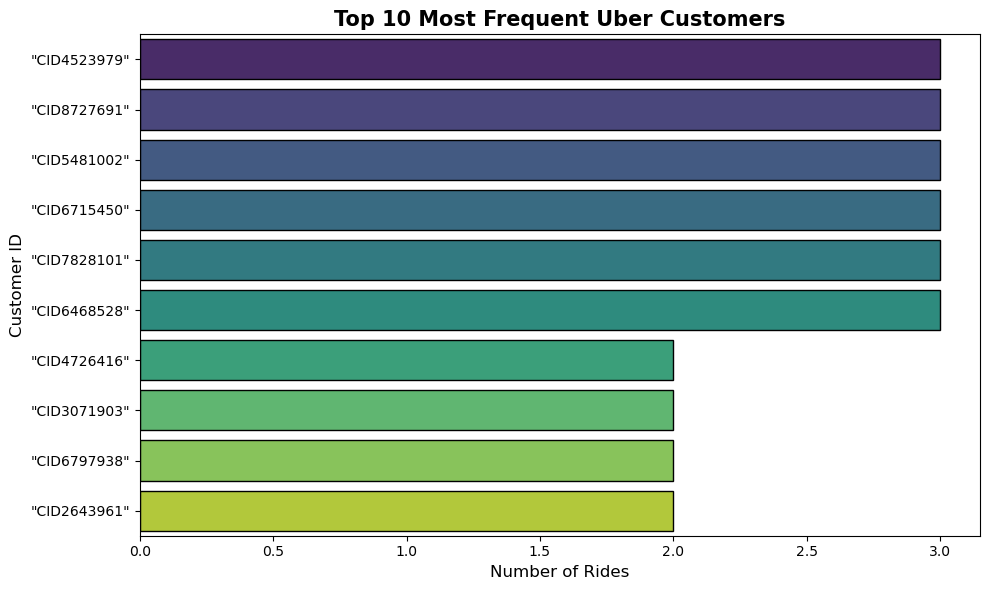

In [106]:
frequent_customer = (
    uber_df['Customer ID']
    .value_counts()
    .head(10)
    .reset_index()
)
df=pd.DataFrame(frequent_customer)
print(df)
frequent_customer.columns = ['Customer ID', 'Ride Count']

plt.figure(figsize=(10,6))
sns.barplot(
    data=frequent_customer,
    y='Customer ID',
    x='Ride Count',
    palette='viridis',
    edgecolor='black'
    
)

plt.title('Top 10 Most Frequent Uber Customers', fontsize=15, fontweight='bold')
plt.xlabel('Number of Rides', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.show()

In [103]:

print("KEY PRICING INSIGHTS")
print(f"Overall Average Fare     : ₹{uber_df['Booking Value'].mean():.2f}")
print(f"Median Fare              : ₹{uber_df['Booking Value'].median():.2f}")
print("=== Booking Value Summary ===")
print(uber_df['Booking Value'].describe())

KEY PRICING INSIGHTS
Overall Average Fare     : ₹478.12
Median Fare              : ₹414.00
=== Booking Value Summary ===
count    150000.000000
mean        478.121220
std         329.339976
min          50.000000
25%         319.750000
50%         414.000000
75%         521.000000
max        4277.000000
Name: Booking Value, dtype: float64


C:\Users\hai\AppData\Local\Temp\ipykernel_11764\4263106872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=uber_df, x=uber_df['WEEKDAY'],


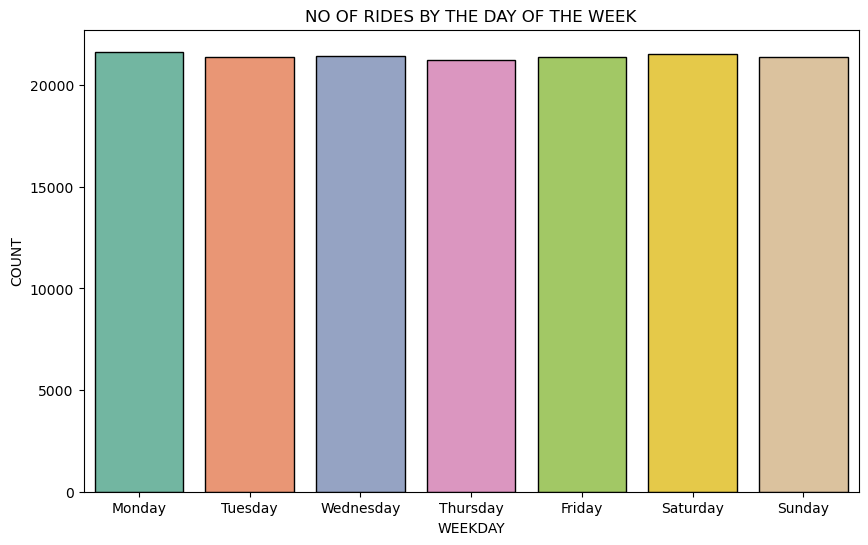

In [108]:
uber_df['Date'] = pd.to_datetime(uber_df['Date'])

uber_df['WEEKDAY'] = uber_df['Date'].dt.day_name()

plt.figure(figsize=(10,6))
sns.countplot(data=uber_df, x=uber_df['WEEKDAY'], 
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], 
              palette='Set2',edgecolor='black')
plt.title('NO OF RIDES BY THE DAY OF THE WEEK')
plt.xlabel('WEEKDAY')
plt.ylabel('COUNT')
plt.show()

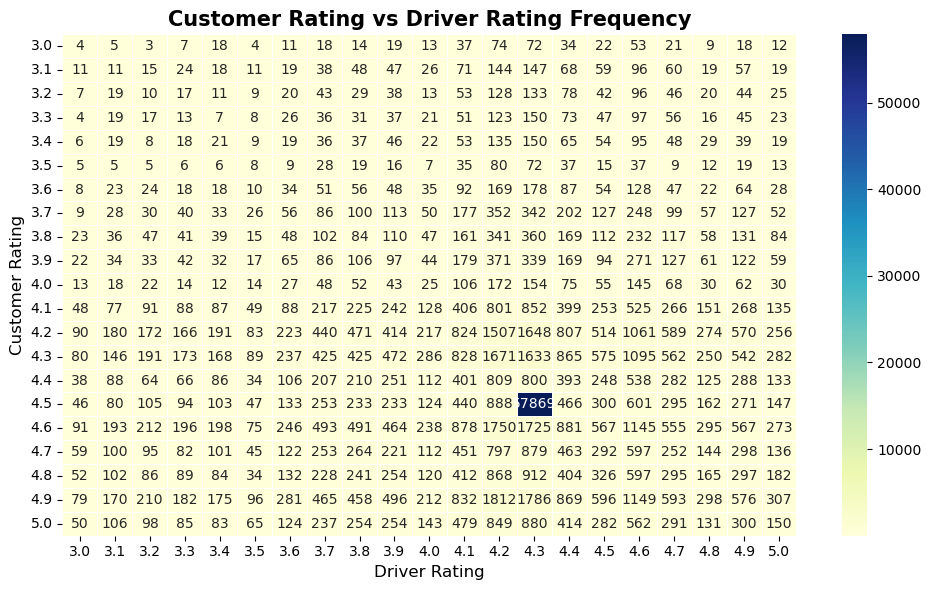

In [114]:
rating_heatmap = uber_df.groupby(['Customer Rating', 'Driver Ratings']).size().unstack(fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title('Customer Rating vs Driver Rating Frequency', fontsize=15, fontweight='bold')
plt.xlabel('Driver Rating', fontsize=12)
plt.ylabel('Customer Rating', fontsize=12)
plt.tight_layout()
plt.show()

In [111]:
pd.DataFrame({'Min':uber_df.groupby(['Drop Location'])['Ride Distance'].min(),
              'Mean':uber_df.groupby(['Drop Location'])['Ride Distance'].mean(),
              'Max':uber_df.groupby(['Drop Location'])['Ride Distance'].max()})

,Min,Mean,Max
Drop Location,,,
AIIMS,1.23,24.475941,49.95
Adarsh Nagar,1.08,24.886047,49.98
Akshardham,1.38,24.226133,49.92
Ambience Mall,1.56,24.635239,49.98
Anand Vihar,1.23,24.217916,49.88
...,...,...,...
Vidhan Sabha,1.65,24.574378,49.89
Vinobapuri,1.25,24.608339,49.51
Vishwavidyalaya,1.24,24.451939,49.92


In [112]:
pd.DataFrame({'Count': uber_df.groupby(['Drop Location'])['Pickup Location'].count(),
              'First': uber_df.groupby(['Drop Location'])['Pickup Location'].first(),
              'Last': uber_df.groupby(['Drop Location'])['Pickup Location'].last()})

,Count,First,Last
Drop Location,,,
AIIMS,850,Vidhan Sabha,Yamuna Bank
Adarsh Nagar,845,Rohini,Jama Masjid
Akshardham,856,Tughlakabad,Golf Course Road
Ambience Mall,836,Badarpur,Preet Vihar
Anand Vihar,830,Kashmere Gate,Pataudi Chowk
...,...,...,...
Vidhan Sabha,868,Mayur Vihar,ITO
Vinobapuri,849,Faridabad Sector 15,Indraprastha
Vishwavidyalaya,846,Qutub Minar,Karol Bagh


In [113]:
pd.DataFrame({'Min': uber_df.groupby(['Drop Location'])['Booking Value'].min(),
          'Mean': uber_df.groupby(['Drop Location'])['Booking Value'].mean(),
              'Max': uber_df.groupby(['Drop Location'])['Booking Value'].max()})

,Min,Mean,Max
Drop Location,,,
AIIMS,50.0,475.222353,3762.0
Adarsh Nagar,53.0,467.146746,3771.0
Akshardham,50.0,474.814252,3841.0
Ambience Mall,52.0,491.693780,3434.0
Anand Vihar,51.0,484.478313,3917.0
...,...,...,...
Vidhan Sabha,50.0,470.125576,3524.0
Vinobapuri,50.0,465.111896,3878.0
Vishwavidyalaya,50.0,485.335697,3921.0


In [ ]:
rating_heatmap = uber_df.groupby(['Booking Value', 'Ride Distance']).size().unstack(fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title('booking rate vs ride distance', fontsize=15, fontweight='bold')
plt.xlabel('booking value', fontsize=12)
plt.ylabel('Ride distance', fontsize=12)
plt.tight_layout()
plt.show()